# GW Data Preprocessing Workflow

This notebook demonstrates the step-by-step preprocessing of gravitational wave strain data for collapsar analysis.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from gwpy.timeseries import TimeSeries

sns.set(style="whitegrid", context="paper", font_scale=1.8)

# Detector configuration
DETECTORS = {
    'H1': {
        'channel_name': 'H1:GW-H',
        't0_gps': 1126259462.423,
        'F_plus': 0.578742411175002,
        'F_cross': -0.45094782109531206,
        'color': 'blue'
    },
    'L1': {
        'channel_name': 'L1:GW-L',
        't0_gps': 1126259462.4160156,
        'F_plus': -0.5274334329518102,
        'F_cross': 0.20520960891727422,
        'color': 'orange'
    }
}

/home/x-ctirapongpra/.local/lib/python3.9/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


## 1. Load Raw Strain Data

Load the raw time-domain strain data and create TimeSeries objects for each detector.

In [2]:
# Load raw strain data
data_dir = '/home/x-ctirapongpra/scratch/gw-collapsar/h(t)'

# Load raw data files
time_data = np.loadtxt(os.path.join(data_dir, 't.txt'), delimiter=',')
hp_x = np.loadtxt(os.path.join(data_dir, 'hp_x.txt'))
hx_x = np.loadtxt(os.path.join(data_dir, 'hx_x.txt'))

# Calculate sample rate
dt = time_data[1] - time_data[0]
sample_rate = 1.0 / dt

# Create TimeSeries for each detector
timeseries_dict = {}
for det_name, det_params in DETECTORS.items():
    # Combine polarizations: h = F+ * hp_x + Fx * hx_x
    h_strain = det_params['F_plus'] * hp_x + det_params['F_cross'] * hx_x
    
    # Calculate duration and center time
    n_samples = len(h_strain)
    duration = (n_samples - 1) * dt
    t_start = det_params['t0_gps'] - duration / 2.0
    
    # Create TimeSeries
    timeseries_dict[det_name] = TimeSeries(
        h_strain,
        sample_rate=sample_rate,
        t0=t_start,
        name=det_params['channel_name'],
        unit='strain'
    )

print(f"Loaded {len(timeseries_dict)} detectors")
print(f"Sample rate: {sample_rate:.2f} Hz")
for det_name, ts in timeseries_dict.items():
    print(f"{det_name}:")
    print(f"  Duration: {ts.duration.value:.3f} s")
    print(f"  Samples: {len(ts)}")
    print(f"  t0: {ts.t0.value:.6f} GPS")

Loaded 2 detectors
Sample rate: 10000.00 Hz
H1:
  Duration: 24.000 s
  Samples: 240000
  t0: 1126259450.423050 GPS
L1:
  Duration: 24.000 s
  Samples: 240000
  t0: 1126259450.416066 GPS


## 2. Scale and Crop to Event Window

Apply scaling factors (signals not loud enough before) and crop to a 4-second window around the event time $t_0$.

In [3]:
# Scale and crop for each detector
ts_cropped = {}
scale_factor = 1e-23
amplify_factor = 5.0
crop_duration = 4.0

for det_name, ts in timeseries_dict.items():
    t0_gps = DETECTORS[det_name]['t0_gps']
    
    # Scale and crop
    ts_scaled = ts * scale_factor * amplify_factor
    ts_cropped[det_name] = ts_scaled.crop(t0_gps - crop_duration/2, t0_gps + crop_duration/2)

    
    print(f"{det_name}: {ts_cropped[det_name].duration.value:.1f}s @ {ts_cropped[det_name].sample_rate.value:.0f} Hz")

H1: 4.0s @ 10000 Hz
L1: 4.0s @ 10000 Hz


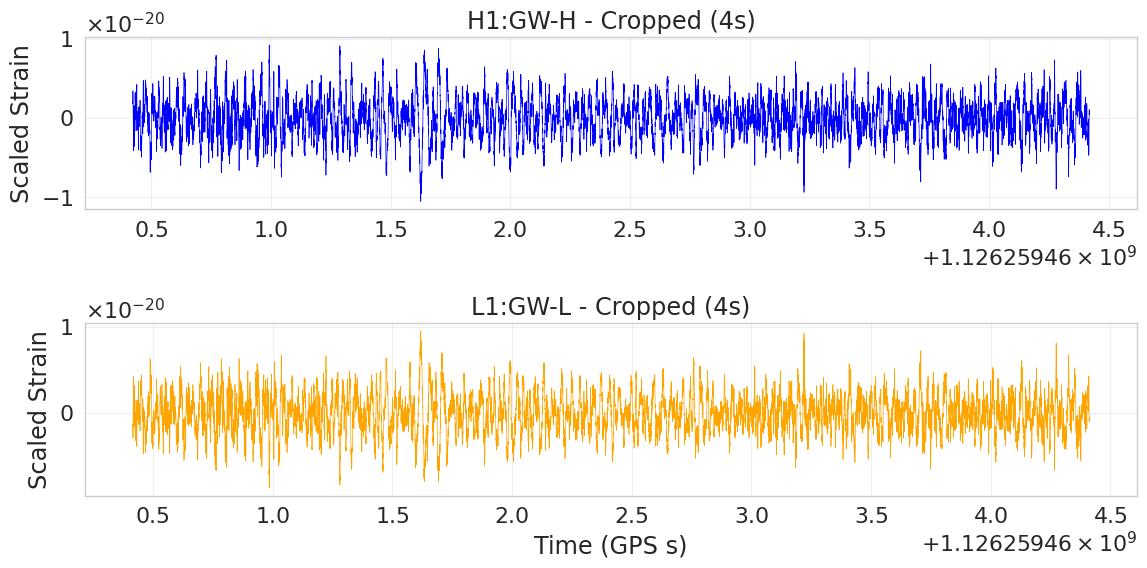

In [4]:
# Visualize cropped signals
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

for idx, (det_name, ts) in enumerate(ts_cropped.items()):
    ax = axes[idx]
    ax.plot(ts.times.value, ts.value, color=DETECTORS[det_name]['color'], linewidth=0.5)
    ax.set_title(f"{DETECTORS[det_name]['channel_name']} - Cropped (4s)")
    ax.set_ylabel('Scaled Strain')
    ax.grid(True, alpha=0.3)
    
axes[1].set_xlabel('Time (GPS s)')
plt.tight_layout()
plt.show()

## 3. Preprocess

- **Resample** from the original ~10 kHz to 4096 Hz using gwpy's built-in resample method.

In [5]:
# Resample to 4096 Hz
ts_resampled = {}
target_sample_rate = 4096

for det_name, ts in ts_cropped.items():
    ts_resampled[det_name] = ts.resample(target_sample_rate)
    
    print(f"{det_name}: {len(ts_resampled[det_name])} samples @ {ts_resampled[det_name].sample_rate.value:.0f} Hz")

H1: 16384 samples @ 4096 Hz
L1: 16384 samples @ 4096 Hz


- **Padding:** Add zero-padding symmetrically on both sides to reach a total (target) duration of 8 seconds, centered on $t_0$.

In [6]:
# Pad to 8 seconds
ts_padded = {}
target_duration = 8.0

for det_name, ts in ts_resampled.items():
    t0_gps = DETECTORS[det_name]['t0_gps']
    
    target_samples = int(target_duration * ts.sample_rate.value)
    current_samples = len(ts)
    
    if current_samples < target_samples:
        # Calculate total padding needed
        total_padding_samples = target_samples - current_samples
        
        # Split padding symmetrically
        pad_left = total_padding_samples // 2
        pad_right = total_padding_samples - pad_left
        
        # Pad symmetrically
        ts_temp = ts.pad((pad_left, pad_right))
        
        # Shift to center the signal on the event time
        # Calculate how much to shift: desired_t0 - current_t0
        desired_t0 = t0_gps - (target_samples / (2.0 * ts.sample_rate.value))
        shift_amount = desired_t0 - ts_temp.t0.value
        ts_temp.shift(shift_amount)
        ts_padded[det_name] = ts_temp
    else:
        ts_padded[det_name] = ts
    
    print(f"{det_name}: {ts_padded[det_name].duration.value:.1f}s, {len(ts_padded[det_name])} samples")

H1: 8.0s, 32768 samples
L1: 8.0s, 32768 samples


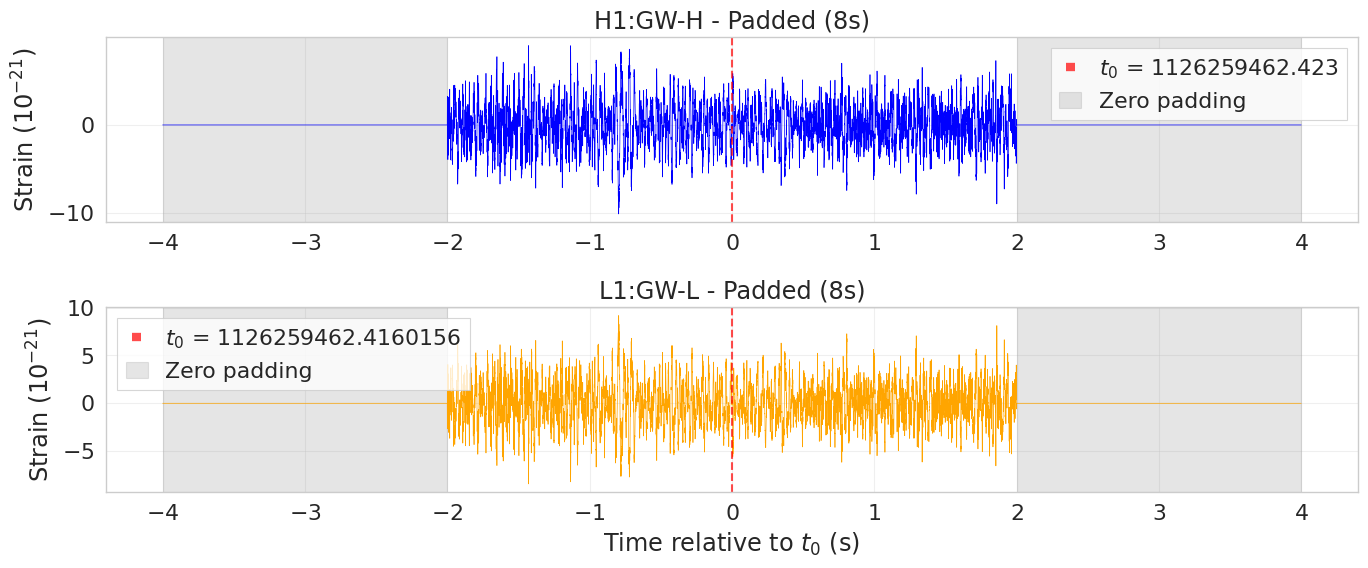

In [7]:
# Visualize padded signals
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

for idx, (det_name, ts) in enumerate(ts_padded.items()):
    ax = axes[idx]
    t0_gps = DETECTORS[det_name]['t0_gps']
    
    # Plot time relative to t0
    time_rel = ts.times.value - t0_gps
    ax.plot(time_rel, ts.value / 1e-21, linewidth=0.5, color=DETECTORS[det_name]['color'])
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'$t_0$ = {t0_gps}')
    ax.axvspan(-4, -2, alpha=0.2, color='gray', label='Zero padding')
    ax.axvspan(2, 4, alpha=0.2, color='gray')
    ax.set_title(f"{DETECTORS[det_name]['channel_name']} - Padded (8s)")
    ax.set_ylabel('Strain ($10^{-21}$)')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Time relative to $t_0$ (s)')
plt.tight_layout()
plt.show()

- **Tapering:** Apply a Tukey window to smoothly taper the edges of the signal to zero, reducing spectral leakage.

In [8]:
# Apply Tukey taper
ts_final = {}
tukey_alpha = 0.1

for det_name, ts in ts_padded.items():
    tukey_window = signal.windows.tukey(len(ts), alpha=tukey_alpha)
    ts_final[det_name] = ts * tukey_window
    
    print(f"{det_name}: Final duration = {ts_final[det_name].duration.value:.1f}s")

H1: Final duration = 8.0s
L1: Final duration = 8.0s


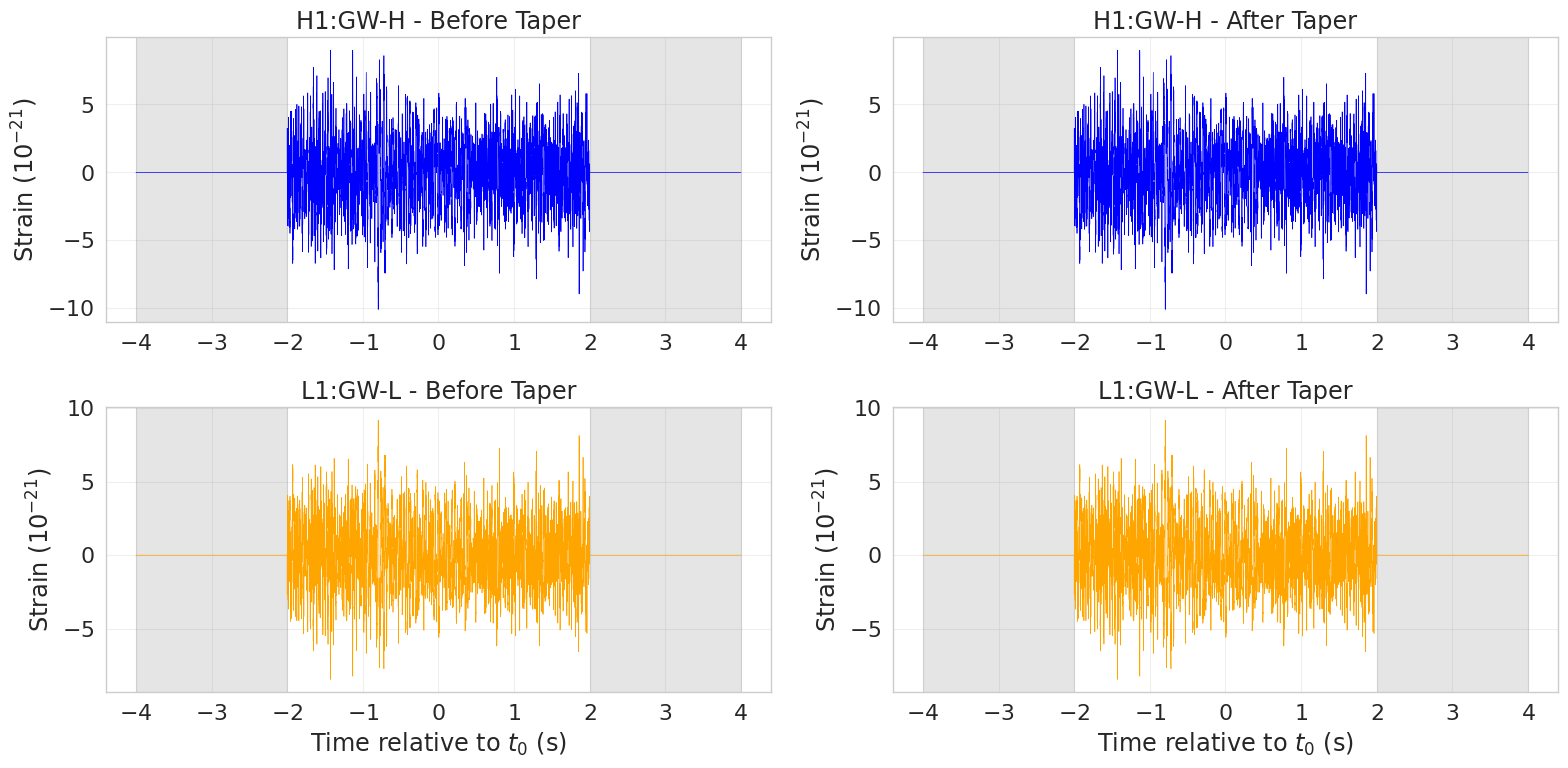

In [9]:
# Visualize effect of taper
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for idx, det_name in enumerate(ts_final.keys()):
    t0_gps = DETECTORS[det_name]['t0_gps']
    color = DETECTORS[det_name]['color']
    
    # Before taper (left column)
    ax_before = axes[idx, 0]
    time_rel = ts_padded[det_name].times.value - t0_gps
    ax_before.plot(time_rel, ts_padded[det_name].value / 1e-21, 
                   linewidth=0.5, color=color)
    ax_before.set_title(f"{DETECTORS[det_name]['channel_name']} - Before Taper")
    ax_before.set_ylabel('Strain ($10^{-21}$)')
    ax_before.grid(True, alpha=0.3)
    ax_before.axvspan(-4, -2, alpha=0.2, color='gray', label='Zero padding')
    ax_before.axvspan(2, 4, alpha=0.2, color='gray')
    
    # After taper (right column)
    ax_after = axes[idx, 1]
    time_rel = ts_final[det_name].times.value - t0_gps
    ax_after.plot(time_rel, ts_final[det_name].value / 1e-21, 
                  linewidth=0.5, color=color)
    ax_after.set_title(f"{DETECTORS[det_name]['channel_name']} - After Taper")
    ax_after.set_ylabel('Strain ($10^{-21}$)')
    ax_after.grid(True, alpha=0.3)
    ax_after.axvspan(-4, -2, alpha=0.2, color='gray', label='Zero padding')
    ax_after.axvspan(2, 4, alpha=0.2, color='gray')

for ax in axes[1, :]:
    ax.set_xlabel('Time relative to $t_0$ (s)')

plt.tight_layout()
plt.show()

## 4. Export to GWF Format

Write the preprocessed time series to GWF (Gravitational Wave Frame) files for use with BayesWave.

In [10]:
# Write to GWF files
print("\nGWF files created:")
for det_name, ts in ts_final.items():
    filename = f'{det_name}.gwf'
    ts.write(filename, format='gwf')
    print(f"{filename}")
    print(f" Written {len(ts)} samples at {ts.sample_rate.value} Hz")
    print(f" Total duration: {ts.duration.value} seconds")
    print(f" t0: {ts.t0.value}")


GWF files created:
H1.gwf
 Written 32768 samples at 4096.0 Hz
 Total duration: 8.0 seconds
 t0: 1126259458.423
L1.gwf
 Written 32768 samples at 4096.0 Hz
 Total duration: 8.0 seconds
 t0: 1126259458.4160156


## 5. Calculate and Save Power Spectral Densities

Compute PSDs using Welch's method and save them for noise characterization.

In [11]:
# Calculate PSDs using Welch's method
psd_dict = {}
fftlength = 4
overlap = 2

for det_name, ts in ts_final.items():
    psd_dict[det_name] = ts.psd(fftlength=fftlength, overlap=overlap)

print("PSD computed for:")
for det_name, psd in psd_dict.items():
    print(f"  {det_name}: {len(psd)} frequency bins, df = {psd.df.value:.2f} Hz")

PSD computed for:
  H1: 8193 frequency bins, df = 0.25 Hz
  L1: 8193 frequency bins, df = 0.25 Hz


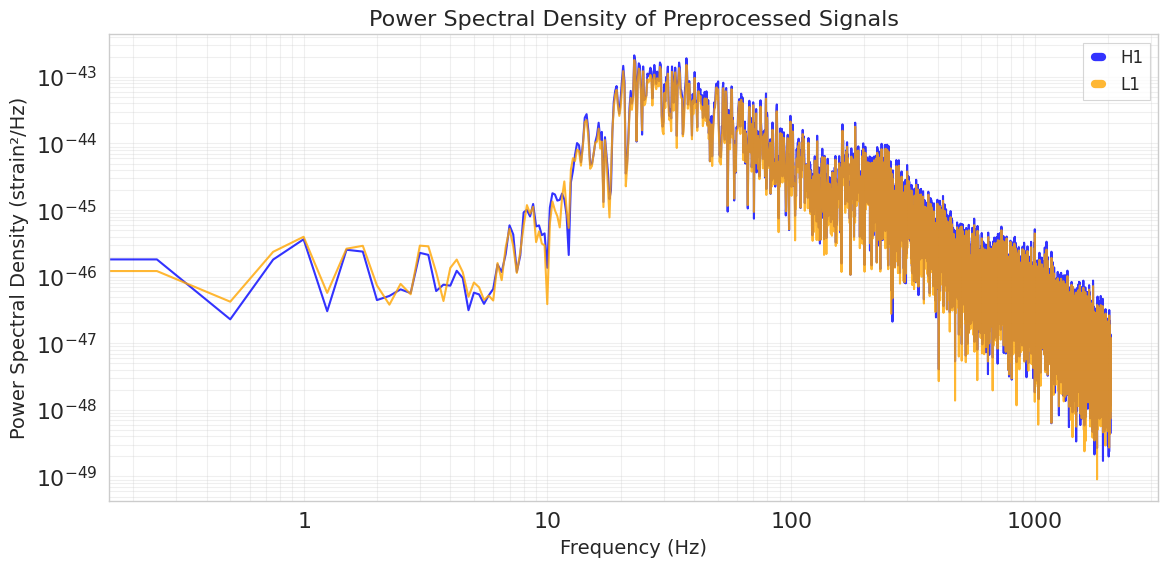

In [12]:
# Visualize PSDs
fig, ax = plt.subplots(figsize=(12, 6))

ax.loglog(psd_dict['H1'].frequencies.value, psd_dict['H1'].value,
          color=DETECTORS['H1']['color'], linewidth=1.5, label='H1', alpha=0.8)
ax.loglog(psd_dict['L1'].frequencies.value, psd_dict['L1'].value,
          color=DETECTORS['L1']['color'], linewidth=1.5, label='L1', alpha=0.8)

ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel('Power Spectral Density (strain²/Hz)', fontsize=14)
ax.set_title('Power Spectral Density of Preprocessed Signals', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [13]:
# Save PSDs to files
for det_name, psd in psd_dict.items():
    filename = f'{det_name}_psd.dat'
    
    # Remove the last frequency bin (Nyquist frequency) for BayesWave compatibility
    psd_truncated = psd[:-1]
    
    np.savetxt(
        filename,
        np.column_stack([psd_truncated.frequencies.value, psd_truncated.value]),
        delimiter=' '
    )
    
    print(f"{filename}")
    print(f" Frequency range: {psd_truncated.frequencies.value[0]:.2f} - {psd_truncated.frequencies.value[-1]:.2f} Hz")
    print(f" Number of bins: {len(psd_truncated)}, N*df = {len(psd_truncated) * psd_truncated.df.value:.2f} Hz")

H1_psd.dat
 Frequency range: 0.00 - 2047.75 Hz
 Number of bins: 8192, N*df = 2048.00 Hz
L1_psd.dat
 Frequency range: 0.00 - 2047.75 Hz
 Number of bins: 8192, N*df = 2048.00 Hz
